# 03 - Feature Engineering

## Objectives
- Create engineered features from existing data
- Encode categorical variables for machine learning
- Prepare final feature matrix for modeling
- Create both early-intervention and full model datasets

**Key Decisions**:
- Which features to engineer
- How to handle categorical variables
- Whether to use 2nd semester data

## 3.1 Setup and imports

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import yaml
from pathlib import Path
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, OneHotEncoder,
    LabelEncoder, OrdinalEncoder
)
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

import joblib

In [36]:
from src.config.configuration import load_config
from src.data.preprocess import load_raw_data, substitute_data, enforce_data_type, get_basic_info

In [37]:
sys.path.append('..')

Display settings

In [38]:
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:.3f}'.format)

Visualization

In [39]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

## 3.2 Load data and config

Load the data (EDA-processed)

In [40]:
df = load_raw_data('student_dropout_academic_success.csv')
df = df[df['Target'] != 'Enrolled']
df = enforce_data_type(df)

print(f"\nDataset shape: {df.shape}")
print(f"Columns: {len(df.columns)}")

Loading data from: /Users/adrienkt/DataspellProjects/student-dropout-classifier/notebooks/../data/raw/student_dropout_academic_success.csv
Dataset loaded: 4424 rows, 37 columns
Enforcing data types...
  Gender -> int (binary)
  Scholarship holder -> int (binary)
  Debtor -> int (binary)
  Tuition fees up to date -> int (binary)
  Displaced -> int (binary)
  Educational special needs -> int (binary)
  International -> int (binary)
  Daytime/evening attendance -> int (binary)
  Mother's qualification -> int (ordinal)
  Father's qualification -> int (ordinal)
  Course -> category (nominal)
  Application mode -> category (nominal)
  Application order -> category (nominal)
  Mother's occupation -> category (nominal)
  Father's occupation -> category (nominal)
  Previous qualification -> category (nominal)
  Marital status -> category (nominal)
  Nacionality -> category (nominal)
  Age at enrollment -> float (continuous)
  Previous qualification (grade) -> float (continuous)
  Admission grad

Load feature configuration

In [41]:
config = load_config("feature_config.yaml")
print("- Feature config loaded")

- Feature config loaded


Display current column types

In [42]:
print(f"\nCurrent data types:")
print(df.dtypes.value_counts())


Current data types:
float64    18
int64      10
object      9
Name: count, dtype: int64


## 3.3 Define Feature Categories

In [43]:
# Define feature groups based on config or manually
if config:
    binary_features = [f.get('original_column', f.get('name')) 
                      for f in config.get('binary_features', [])]
    ordinal_features = [f.get('original_column', f.get('name')) 
                       for f in config.get('ordinal_features', [])]
    nominal_features = [f.get('original_column', f.get('name')) 
                       for f in config.get('nominal_features', [])]
else:
    binary_features = [
        'Gender', 'Scholarship holder', 'Debtor',
        'Tuition fees up to date', 'Displaced',
        'Educational special needs', 'International',
        'Daytime/evening attendance'
    ]
    ordinal_features = ["Mother's qualification", "Father's qualification"]
    nominal_features = [
        'Course', 'Application mode', 'Application order',
        "Mother's occupation", "Father's occupation",
        'Previous qualification', 'Marital status', 'Nacionality'
    ]

# Continuous features (all remaining numeric columns)
exclude_from_continuous = (
    binary_features + ordinal_features + nominal_features + 
    ['Target', 'Dropout_numeric', 'Target_encoded']
)
continuous_features = [
    col for col in df.select_dtypes(include=['int64', 'float64']).columns 
    if col not in exclude_from_continuous
]

# Filter to only columns that exist in the dataframe
binary_features = [f for f in binary_features if f in df.columns]
ordinal_features = [f for f in ordinal_features if f in df.columns]
nominal_features = [f for f in nominal_features if f in df.columns]
continuous_features = [f for f in continuous_features if f in df.columns]

print("Feature Categories:")
print(f"  Binary features:     {len(binary_features)}")
print(f"  Ordinal features:    {len(ordinal_features)}")
print(f"  Nominal features:    {len(nominal_features)}")
print(f"  Continuous features: {len(continuous_features)}")

# Separate 1st and 2nd semester features
sem1_features = [f for f in continuous_features if '1st sem' in f]
sem2_features = [f for f in continuous_features if '2nd sem' in f]
other_continuous = [f for f in continuous_features 
                   if f not in sem1_features + sem2_features]

print(f"\n  - 1st semester: {len(sem1_features)}")
print(f"  - 2nd semester: {len(sem2_features)}")
print(f"  - Other numeric: {len(other_continuous)}")

Feature Categories:
  Binary features:     8
  Ordinal features:    2
  Nominal features:    8
  Continuous features: 18

  - 1st semester: 6
  - 2nd semester: 6
  - Other numeric: 6


## 3.4 Create Engineered Features

In [44]:
new_features = []

### 3.4.1 Academic Performance Rates

In [45]:
# 1st Semester Approval Rate
if 'Curricular units 1st sem (approved)' in df.columns and \
   'Curricular units 1st sem (enrolled)' in df.columns:
    df['approval_rate_sem1'] = np.where(
        df['Curricular units 1st sem (enrolled)'] > 0,
        (df['Curricular units 1st sem (approved)'] /
         df['Curricular units 1st sem (enrolled)']) * 100,
        0
    )
    new_features.append('approval_rate_sem1')
    print(f"- approval_rate_sem1: {df['approval_rate_sem1'].min():.0f}% - {df['approval_rate_sem1'].max():.0f}%")

# 2nd Semester Approval Rate
if 'Curricular units 2nd sem (approved)' in df.columns and \
   'Curricular units 2nd sem (enrolled)' in df.columns:
    df['approval_rate_sem2'] = np.where(
        df['Curricular units 2nd sem (enrolled)'] > 0,
        (df['Curricular units 2nd sem (approved)'] /
         df['Curricular units 2nd sem (enrolled)']) * 100,
        0
    )
    new_features.append('approval_rate_sem2')
    print(f"- approval_rate_sem2: {df['approval_rate_sem2'].min():.0f}% - {df['approval_rate_sem2'].max():.0f}%")

- approval_rate_sem1: 0% - 100%
- approval_rate_sem2: 0% - 100%


### 3.4.2 Grade Momentum and Changes

In [46]:
# Grade momentum (Admission → 1st Semester)
if 'Curricular units 1st sem (grade)' in df.columns and \
   'Admission grade' in df.columns:
    # Normalize admission grade to 0-20 scale for fair comparison
    df['grade_momentum'] = df['Curricular units 1st sem (grade)'] - (df['Admission grade'] / 10)
    new_features.append('grade_momentum')
    print(f"- grade_momentum: {df['grade_momentum'].min():.1f} to {df['grade_momentum'].max():.1f}")
    print(f"   (Positive = improvement from admission, Negative = decline)")

# Grade decline (1st → 2nd Semester)
if 'Curricular units 1st sem (grade)' in df.columns and \
   'Curricular units 2nd sem (grade)' in df.columns:
    df['grade_decline'] = df['Curricular units 1st sem (grade)'] - df['Curricular units 2nd sem (grade)']
    new_features.append('grade_decline')
    print(f"- grade_decline: {df['grade_decline'].min():.1f} to {df['grade_decline'].max():.1f}")
    print(f"   (Positive = grades dropped, Negative = grades improved)")

- grade_momentum: -18.0 to 6.1
   (Positive = improvement from admission, Negative = decline)
- grade_decline: -14.5 to 16.1
   (Positive = grades dropped, Negative = grades improved)


### 3.4.3 Course Load and Intensity

In [47]:
# Evaluation intensity (assessments per enrolled course)
if 'Curricular units 1st sem (evaluations)' in df.columns and \
   'Curricular units 1st sem (enrolled)' in df.columns:
    df['evaluation_intensity_sem1'] = np.where(
        df['Curricular units 1st sem (enrolled)'] > 0,
        df['Curricular units 1st sem (evaluations)'] / df['Curricular units 1st sem (enrolled)'],
        0
    )
    new_features.append('evaluation_intensity_sem1')
    print(f"- evaluation_intensity_sem1: {df['evaluation_intensity_sem1'].min():.1f} - {df['evaluation_intensity_sem1'].max():.1f}")

# Credit utilization (prior credits vs enrolled)
if 'Curricular units 1st sem (credited)' in df.columns and \
   'Curricular units 1st sem (enrolled)' in df.columns:
    df['credit_utilization_sem1'] = np.where(
        df['Curricular units 1st sem (enrolled)'] > 0,
        df['Curricular units 1st sem (credited)'] / df['Curricular units 1st sem (enrolled)'],
        0
    )
    new_features.append('credit_utilization_sem1')
    print(f"- credit_utilization_sem1: {df['credit_utilization_sem1'].min():.2f} - {df['credit_utilization_sem1'].max():.2f}")

# Total course load
if 'Curricular units 1st sem (enrolled)' in df.columns and \
   'Curricular units 2nd sem (enrolled)' in df.columns:
    df['total_course_load'] = (
        df['Curricular units 1st sem (enrolled)'] + df['Curricular units 2nd sem (enrolled)']
    )
    new_features.append('total_course_load')
    print(f"- total_course_load: {df['total_course_load'].min():.0f} - {df['total_course_load'].max():.0f} units")

- evaluation_intensity_sem1: 0.0 - 3.5
- credit_utilization_sem1: 0.00 - 1.00
- total_course_load: 0 - 46 units


### 3.4.4 Financial & Socioeconomic Composites

In [48]:
# Financial stress score
if all(c in df.columns for c in ['Debtor', 'Tuition fees up to date', 'Scholarship holder']):
    df['financial_stress'] = (
        df['Debtor'] +
        (1 - df['Tuition fees up to date']) +
        (1 - df['Scholarship holder'])
    )
    new_features.append('financial_stress')
    print(f"- financial_stress: {df['financial_stress'].min():.0f} - {df['financial_stress'].max():.0f}")
    print(f"   (0 = no stress, 3 = maximum stress)")

# Parental education level (average)
if "Mother's qualification" in df.columns and "Father's qualification" in df.columns:
    df['parent_education'] = (
        df["Mother's qualification"] + df["Father's qualification"]
    ) / 2
    new_features.append('parent_education')
    print(f"- parent_education: {df['parent_education'].min():.1f} - {df['parent_education'].max():.1f}")

- financial_stress: 0 - 3
   (0 = no stress, 3 = maximum stress)
- parent_education: 1.0 - 42.0


### 3.4.5 Engagement & Risk Indicators

In [49]:
# Without evaluations flag (disengagement indicator)
if 'Curricular units 1st sem (without evaluations)' in df.columns:
    # If student enrolled but didn't take evaluations, they're disengaged
    df['disengagement_sem1'] = (
        df['Curricular units 1st sem (without evaluations)'] > 0
    ).astype(int)
    new_features.append('disengagement_sem1')
    print(f"- disengagement_sem1: {df['disengagement_sem1'].sum()} students ({df['disengagement_sem1'].mean()*100:.1f}%)")

# Perfect score flag (all courses approved)
if all(c in df.columns for c in ['Curricular units 1st sem (approved)', 'Curricular units 1st sem (enrolled)']):
    df['perfect_sem1'] = (
        df['Curricular units 1st sem (approved)'] == df['Curricular units 1st sem (enrolled)']
    ).astype(int)
    new_features.append('perfect_sem1')
    print(f"- perfect_sem1: {df['perfect_sem1'].sum()} students ({df['perfect_sem1'].mean()*100:.1f}%)")

- disengagement_sem1: 224 students (6.2%)
- perfect_sem1: 1698 students (46.8%)


### 3.4.6 Summary

In [50]:
print(f"\n- Total new features created: {len(new_features)}")
print(f"New features: {new_features}")
print(f"Updated dataframe shape: {df.shape}")


- Total new features created: 11
New features: ['approval_rate_sem1', 'approval_rate_sem2', 'grade_momentum', 'grade_decline', 'evaluation_intensity_sem1', 'credit_utilization_sem1', 'total_course_load', 'financial_stress', 'parent_education', 'disengagement_sem1', 'perfect_sem1']
Updated dataframe shape: (3630, 48)


## 3.5 Validate Engineered Features

Check correlations with dropout for new features

In [51]:
if 'Dropout_numeric' in df.columns:
    new_feature_corrs = df[new_features + ['Dropout_numeric']].corr()['Dropout_numeric'].drop('Dropout_numeric')
    new_feature_corrs = new_feature_corrs.sort_values(ascending=False)

    print("\nCorrelation of engineered features with Dropout:")
    print("-" * 55)
    for feat, corr in new_feature_corrs.items():
        bar = '█' * int(abs(corr) * 50)
        direction = '- RISK' if corr > 0 else '- PROTECTIVE'
        print(f"  {feat:<35s} | {corr:+.3f} {bar} {direction}")
else:
    # Create numeric target if not present
    df['Dropout_numeric'] = (df['Target'] == 'Dropout').astype(int)
    new_feature_corrs = df[new_features + ['Dropout_numeric']].corr()['Dropout_numeric'].drop('Dropout_numeric')
    new_feature_corrs = new_feature_corrs.sort_values(ascending=False)

    print("\nCorrelation of engineered features with Dropout:")
    print("-" * 55)
    for feat, corr in new_feature_corrs.items():
        bar = '█' * int(abs(corr) * 50)
        print(f"  {feat:<35s} | {corr:+.3f} {bar}")


Correlation of engineered features with Dropout:
-------------------------------------------------------
  financial_stress                    | +0.493 ████████████████████████
  grade_decline                       | +0.233 ███████████
  disengagement_sem1                  | +0.085 ████
  evaluation_intensity_sem1           | +0.053 ██
  parent_education                    | +0.034 █
  credit_utilization_sem1             | -0.026 █
  total_course_load                   | -0.174 ████████
  grade_momentum                      | -0.477 ███████████████████████
  perfect_sem1                        | -0.494 ████████████████████████
  approval_rate_sem1                  | -0.670 █████████████████████████████████
  approval_rate_sem2                  | -0.740 █████████████████████████████████████


Check for NaN values in new features

In [52]:
nan_counts = df[new_features].isnull().sum()
if nan_counts.sum() > 0:
    print(f"\n-  NaN values found in engineered features:")
    for feat, count in nan_counts[nan_counts > 0].items():
        print(f"    {feat}: {count} NaN values")
    # Fill NaN with 0 for ratio features
    df[new_features] = df[new_features].fillna(0)
    print("  - NaN values filled with 0")
else:
    print("\n- No NaN values in engineered features")


- No NaN values in engineered features


## 3.6 Encode Target Variable

In [53]:
# Create binary target
df['Target_encoded'] = (df['Target'] == 'Dropout').astype(int)

print(f"Target encoding: Dropout=1, Graduate=0")
print(f"\nDistribution:")
print(f"  Dropout (1):  {df['Target_encoded'].sum():4d} ({df['Target_encoded'].mean()*100:.1f}%)")
print(f"  Graduate (0): {(1 - df['Target_encoded']).sum():4d} ({(1-df['Target_encoded'].mean())*100:.1f}%)")

Target encoding: Dropout=1, Graduate=0

Distribution:
  Dropout (1):  1421 (39.1%)
  Graduate (0): 2209 (60.9%)


## 3.7 Handle Categorical Encoding

In [54]:
# Strategy:
# - Binary features: Keep as 0/1 (already encoded)
# - Ordinal features: Keep as integers (preserve ordering)
# - Nominal features: One-hot encode (no ordering assumed)

# Identify high-cardinality nominal features (many categories)
high_cardinality = {}
for col in nominal_features:
    if col in df.columns:
        n_unique = df[col].nunique()
        high_cardinality[col] = n_unique
        if n_unique > 10:
            print(f"  -  High cardinality: '{col}' has {n_unique} unique values")

print(f"\n  Nominal features to one-hot encode: {len(nominal_features)}")
for col in nominal_features:
    if col in df.columns:
        print(f"    - {col}: {df[col].nunique()} categories")

# Convert nominal features to object type for OneHotEncoder
for col in nominal_features:
    if col in df.columns:
        df[col] = df[col].astype(str)

  -  High cardinality: 'Course' has 17 unique values
  -  High cardinality: 'Application mode' has 18 unique values
  -  High cardinality: 'Mother's occupation' has 29 unique values
  -  High cardinality: 'Father's occupation' has 42 unique values
  -  High cardinality: 'Previous qualification' has 17 unique values
  -  High cardinality: 'Nacionality' has 19 unique values

  Nominal features to one-hot encode: 8
    - Course: 17 categories
    - Application mode: 18 categories
    - Application order: 7 categories
    - Mother's occupation: 29 categories
    - Father's occupation: 42 categories
    - Previous qualification: 17 categories
    - Marital status: 6 categories
    - Nacionality: 19 categories


## 3.8 Build Preprocessing Pipelines

### 3.8.1 Define feature columns for modeling

In [55]:
# Columns to exclude from features
exclude_cols = [
    'Target', 'Target_encoded', 'Dropout_numeric',
    # Remove any temporary/leakage columns
]

# All feature columns
all_feature_cols = (
    binary_features + ordinal_features + nominal_features +
    continuous_features + new_features
)
all_feature_cols = [c for c in all_feature_cols
                   if c in df.columns and c not in exclude_cols]

# Remove duplicates while preserving order
all_feature_cols = list(dict.fromkeys(all_feature_cols))

print(f"Total feature columns for modeling: {len(all_feature_cols)}")

Total feature columns for modeling: 47


### 3.8.2 Create preprocessing pipelines

#### Pipeline A: For Linear Models (One-Hot + Scaling)

In [56]:
print("\n--- Pipeline A: Linear Models ---")

# Separate features into types for ColumnTransformer
nominal_for_encoding = [c for c in nominal_features
                       if c in all_feature_cols]
continuous_for_scaling = [c for c in all_feature_cols
                         if c not in nominal_for_encoding]

preprocessor_linear = ColumnTransformer(
    transformers=[
        ('onehot', OneHotEncoder(drop='first', sparse_output=False,
                                  handle_unknown='ignore'),
         nominal_for_encoding),
        ('scaler', StandardScaler(), continuous_for_scaling)
    ],
    remainder='drop',
    verbose_feature_names_out=False
)

print(f"  OneHotEncoder: {len(nominal_for_encoding)} features")
print(f"  StandardScaler: {len(continuous_for_scaling)} features")


--- Pipeline A: Linear Models ---
  OneHotEncoder: 8 features
  StandardScaler: 39 features


#### Pipeline B: For Tree-Based Models (Label Encoding, No Scaling)

In [57]:
print("\n--- Pipeline B: Tree-Based Models ---")

# For tree models, we can use Label Encoding for nominals
df_tree = df.copy()
label_encoders = {}

for col in nominal_features:
    if col in df_tree.columns and col in all_feature_cols:
        le = LabelEncoder()
        df_tree[col] = le.fit_transform(df_tree[col].astype(str))
        label_encoders[col] = le

tree_feature_cols = [c for c in all_feature_cols if c in df_tree.columns]
print(f"  Label Encoded: {len(label_encoders)} nominal features")
print(f"  Total features: {len(tree_feature_cols)}")
print(f"  No scaling applied (tree models don't need it)")


--- Pipeline B: Tree-Based Models ---
  Label Encoded: 8 nominal features
  Total features: 47
  No scaling applied (tree models don't need it)


## 3.9 Create early intervention dataset

In [58]:
# Features available before 2nd semester results
early_exclude_patterns = [
    '2nd sem', 'sem2', 'approval_rate_sem2', 'grade_decline',
    'total_course_load'
]

early_features = [c for c in all_feature_cols 
                 if not any(pattern in c.lower() for pattern in early_exclude_patterns)]

print(f"Early intervention features: {len(early_features)}")
print(f"Excluded 2nd semester features: {len(all_feature_cols) - len(early_features)}")
print(f"\nExcluded features:")
for c in all_feature_cols:
    if c not in early_features:
        print(f"  - {c}")

# Create early intervention datasets
X_early = df[early_features].copy()
y = df['Target_encoded'].copy()

print(f"\nEarly intervention feature matrix: {X_early.shape}")
print(f"Target vector: {y.shape}")

Early intervention features: 38
Excluded 2nd semester features: 9

Excluded features:
  - Curricular units 2nd sem (credited)
  - Curricular units 2nd sem (enrolled)
  - Curricular units 2nd sem (evaluations)
  - Curricular units 2nd sem (approved)
  - Curricular units 2nd sem (grade)
  - Curricular units 2nd sem (without evaluations)
  - approval_rate_sem2
  - grade_decline
  - total_course_load

Early intervention feature matrix: (3630, 38)
Target vector: (3630,)


## 3.10 Train-Test split

In [59]:
# Split for full model
X_full = df_tree[tree_feature_cols].copy()
y_full = df['Target_encoded'].copy()

# First split: separate test set (20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X_full, y_full, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_full
)

# Second split: separate validation from training (25% of remaining = 20% of total)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, 
    test_size=0.25, 
    random_state=42, 
    stratify=y_temp
)

print(f"\nFull Model Splits:")
print(f"  Train:      {X_train.shape[0]:4d} samples ({X_train.shape[0]/len(y)*100:.0f}%)")
print(f"  Validation: {X_val.shape[0]:4d} samples ({X_val.shape[0]/len(y)*100:.0f}%)")
print(f"  Test:       {X_test.shape[0]:4d} samples ({X_test.shape[0]/len(y)*100:.0f}%)")

# Check class distribution
for name, y_set in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    print(f"  {name} dropout rate: {y_set.mean()*100:.1f}%")

# Split for early intervention model
X_early_train, X_early_test, y_early_train, y_early_test = train_test_split(
    X_early, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\nEarly Intervention Model Splits:")
print(f"  Train: {X_early_train.shape[0]:4d} samples")
print(f"  Test:  {X_early_test.shape[0]:4d} samples")
print(f"  Features: {X_early_train.shape[1]}")


Full Model Splits:
  Train:      2178 samples (60%)
  Validation:  726 samples (20%)
  Test:        726 samples (20%)
  Train dropout rate: 39.2%
  Val dropout rate: 39.1%
  Test dropout rate: 39.1%

Early Intervention Model Splits:
  Train: 2904 samples
  Test:   726 samples
  Features: 38


## 3.11 Feature importance preview (Quick check)


Top 20 Most Important Features:
--------------------------------------------------
[NEW] approval_rate_sem2                       | 0.1784 █████████████████
[NEW] approval_rate_sem1                       | 0.1183 ███████████
   Curricular units 2nd sem (approved)      | 0.1148 ███████████
   Curricular units 1st sem (approved)      | 0.0686 ██████
   Curricular units 2nd sem (grade)         | 0.0660 ██████
[NEW] grade_momentum                           | 0.0472 ████
[NEW] financial_stress                         | 0.0376 ███
[NEW] perfect_sem1                             | 0.0354 ███
   Curricular units 1st sem (grade)         | 0.0336 ███
   Tuition fees up to date                  | 0.0276 ██
[NEW] grade_decline                            | 0.0190 █
   Curricular units 2nd sem (evaluations)   | 0.0179 █
[NEW] evaluation_intensity_sem1                | 0.0167 █
   Age at enrollment                        | 0.0160 █
   Course                                   | 0.0159 █
   Previous qu

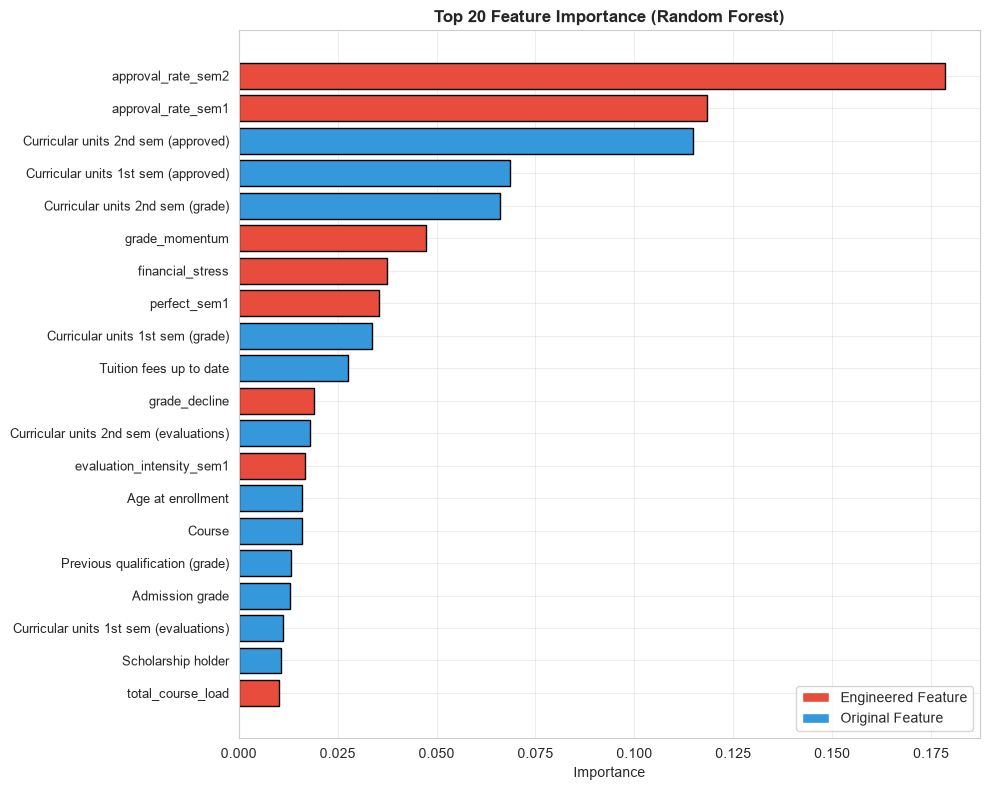

In [60]:
# Train a quick Random Forest to see feature importance
rf_quick = RandomForestClassifier(
    n_estimators=100, 
    max_depth=10, 
    random_state=42, 
    n_jobs=-1
)
rf_quick.fit(X_train, y_train)

# Get feature importance
importance_df = pd.DataFrame({
    'Feature': tree_feature_cols,
    'Importance': rf_quick.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 20 Most Important Features:")
print("-" * 50)
for i, row in importance_df.head(20).iterrows():
    bar = '█' * int(row['Importance'] * 100)
    # Mark engineered features
    marker = '[NEW]' if row['Feature'] in new_features else '  '
    print(f"{marker} {row['Feature']:<40s} | {row['Importance']:.4f} {bar}")

# Count engineered features in top 20
engineered_in_top20 = importance_df.head(20)['Feature'].isin(new_features).sum()
print(f"\n- {engineered_in_top20}/20 of top features are engineered features")

# Visualize
fig, ax = plt.subplots(figsize=(10.0, 8.0))
top_features = importance_df.head(20)
colors = ['#e74c3c' if f in new_features else '#3498db' for f in top_features['Feature']]
ax.barh(range(len(top_features)), top_features['Importance'].values, color=colors, edgecolor='black')
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels([f[:45] + '...' if len(f) > 48 else f for f in top_features['Feature']], fontsize=9)
ax.set_xlabel('Importance')
ax.set_title('Top 20 Feature Importance (Random Forest)', fontweight='bold')
ax.invert_yaxis()

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e74c3c', label='Engineered Feature'),
    Patch(facecolor='#3498db', label='Original Feature')
]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig('../reports/figures/feature_importance_preview.png', dpi=150, bbox_inches='tight')
plt.show()

## 3.12 Save processed datasets

Create output directories

In [61]:
Path('../data/processed').mkdir(parents=True, exist_ok=True)
Path('../models').mkdir(parents=True, exist_ok=True)

### 3.12.1 Save full model datasets

In [62]:
print("\nSaving full model datasets...")

X_train.to_csv('../data/processed/X_train_full.csv', index=False)
print("  - X_train_full.csv")

y_train.to_csv('../data/processed/y_train_full.csv', index=False)
print("  - y_train_full.csv")

X_val.to_csv('../data/processed/X_val_full.csv', index=False)
print("  - X_val_full.csv")

y_val.to_csv('../data/processed/y_val_full.csv', index=False)
print("  - y_val_full.csv")

X_test.to_csv('../data/processed/X_test_full.csv', index=False)
print("  - X_test_full.csv")

y_test.to_csv('../data/processed/y_test_full.csv', index=False)
print("  - y_test_full.csv")


Saving full model datasets...
  - X_train_full.csv
  - y_train_full.csv
  - X_val_full.csv
  - y_val_full.csv
  - X_test_full.csv
  - y_test_full.csv


### 3.12.2 Save early intervention datasets

In [63]:
print("\nSaving early intervention datasets...")

X_early_train.to_csv('../data/processed/X_train_early.csv', index=False)
print("  - X_train_early.csv")

y_early_train.to_csv('../data/processed/y_train_early.csv', index=False)
print("  - y_train_early.csv")

X_early_test.to_csv('../data/processed/X_test_early.csv', index=False)
print("  - X_test_early.csv")

y_early_test.to_csv('../data/processed/y_test_early.csv', index=False)
print("  - y_test_early.csv")


Saving early intervention datasets...
  - X_train_early.csv
  - y_train_early.csv
  - X_test_early.csv
  - y_test_early.csv


### 3.12.3 Save preprocessor for linear models

In [64]:
print("\nSaving preprocessing pipeline...")

# Fit the preprocessor on training data
X_train_for_prep = df[all_feature_cols].loc[X_train.index]
preprocessor_linear.fit(X_train_for_prep)
joblib.dump(preprocessor_linear, '../models/preprocessor_linear.pkl')
print("  - preprocessor_linear.pkl")


Saving preprocessing pipeline...
  - preprocessor_linear.pkl


### 3.12.4 Save feature lists

In [65]:
print("\nSaving feature metadata...")

feature_metadata = {
    'feature_cols': tree_feature_cols,
    'early_features': early_features,
    'new_features': new_features,
    'binary_features': binary_features,
    'ordinal_features': ordinal_features,
    'nominal_features': nominal_features,
    'continuous_features': continuous_features,
    'label_encoders': {k: list(v.classes_) for k, v in label_encoders.items()}
}

with open('../data/processed/feature_metadata.yaml', 'w') as f:
    yaml.dump(feature_metadata, f, default_flow_style=False)
print("  - feature_metadata.yaml")


Saving feature metadata...
  - feature_metadata.yaml


### 3.12.5 Save the full engineered dataframe

In [66]:
df.to_pickle('../data/processed/df_engineered.pkl')
print("  - df_engineered.pkl")

  - df_engineered.pkl


## 3.13 Summary

In [67]:
summary = f"""
DATASET OVERVIEW
─────────────────────────────────
  Total samples:            {len(df):,}
  Original features:        {len(continuous_features) + len(binary_features) + len(ordinal_features) + len(nominal_features)}
  Engineered features:      {len(new_features)}
  Final feature count:      {len(tree_feature_cols)}

MODEL DATASETS CREATED
─────────────────────────────────
  Full Model:
    - {X_train.shape[0]:,} training samples, {X_train.shape[1]} features
    - {X_val.shape[0]:,} validation samples
    - {X_test.shape[0]:,} test samples
    - Includes 2nd semester data

  Early Intervention Model:
    - {X_early_train.shape[0]:,} training samples, {X_early_train.shape[1]} features
    - {X_early_test.shape[0]:,} test samples
    - 1st semester data only

ENGINEERED FEATURES
─────────────────────────────────
  Academic Performance:
    - approval_rate_sem1, approval_rate_sem2
    - grade_momentum, grade_decline
    - evaluation_intensity_sem1
    - credit_utilization_sem1
    - total_course_load

  Socioeconomic:
    - financial_stress (0-3 composite score)
    - parent_education (average parental qualification)

  Engagement:
    - disengagement_sem1 (no evaluations taken)
    - perfect_sem1 (all courses approved)
"""

print(summary)


DATASET OVERVIEW
─────────────────────────────────
  Total samples:            3,630
  Original features:        36
  Engineered features:      11
  Final feature count:      47

MODEL DATASETS CREATED
─────────────────────────────────
  Full Model:
    - 2,178 training samples, 47 features
    - 726 validation samples
    - 726 test samples
    - Includes 2nd semester data

  Early Intervention Model:
    - 2,904 training samples, 38 features
    - 726 test samples
    - 1st semester data only

ENGINEERED FEATURES
─────────────────────────────────
  Academic Performance:
    - approval_rate_sem1, approval_rate_sem2
    - grade_momentum, grade_decline
    - evaluation_intensity_sem1
    - credit_utilization_sem1
    - total_course_load

  Socioeconomic:
    - financial_stress (0-3 composite score)
    - parent_education (average parental qualification)

  Engagement:
    - disengagement_sem1 (no evaluations taken)
    - perfect_sem1 (all courses approved)



## Appendix: Quick data quality check

In [68]:
# Check for any remaining issues
issues = []

# Check training data
if X_train.isnull().any().any():
    null_cols = X_train.columns[X_train.isnull().any()].tolist()
    issues.append(f"NaN values in training features: {null_cols}")

if y_train.isnull().any():
    issues.append("NaN values in training target")

# Check for infinite values
if np.isinf(X_train.select_dtypes(include=['float64'])).any().any():
    issues.append("Infinite values in training features")

# Check class balance
dropout_pct = y_train.mean() * 100
if dropout_pct < 20 or dropout_pct > 80:
    issues.append(f"Class imbalance: {dropout_pct:.1f}% dropout rate")

# Check feature variance
low_variance = []
for col in X_train.columns:
    if X_train[col].nunique() <= 1:
        low_variance.append(col)
if low_variance:
    issues.append(f"Zero-variance features: {low_variance}")

if issues:
    print("-  Issues found:")
    for issue in issues:
        print(f"  - {issue}")
else:
    print("- All checks passed! Data is ready for modeling.")

print(f"\nTraining features shape: {X_train.shape}")
print(f"Training target shape:   {y_train.shape}")
print(f"Feature dtypes:\n{X_train.dtypes.value_counts()}")

- All checks passed! Data is ready for modeling.

Training features shape: (2178, 47)
Training target shape:   (2178,)
Feature dtypes:
float64    26
int64      21
Name: count, dtype: int64
